In [8]:
import pandas as pd

ds =  pd.read_csv("house_prices.csv")

#Loading and inspecting

ds.head()

ds.info()

ds.isnull().sum()

ds.duplicated().sum()



<class 'pandas.DataFrame'>
RangeIndex: 532 entries, 0 to 531
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   HouseID           532 non-null    str    
 1   Area_sqft         532 non-null    int64  
 2   Bedrooms          532 non-null    int64  
 3   Bathrooms         504 non-null    float64
 4   Age_years         532 non-null    int64  
 5   City              532 non-null    str    
 6   FurnishingStatus  511 non-null    str    
 7   Parking           532 non-null    int64  
 8   MainRoad          532 non-null    str    
 9   Price             532 non-null    float64
dtypes: float64(2), int64(4), str(4)
memory usage: 41.7 KB


np.int64(12)

In [10]:
#Remove Duplicates
ds.drop_duplicates()

,HouseID,Area_sqft,Bedrooms,Bathrooms,Age_years,City,FurnishingStatus,Parking,MainRoad,Price
0,H0402,2294,5,2.0,27,Delhi,FURNISHED,0,YES,13121696.24
1,H0176,1908,1,2.0,4,Pune,furnished,0,YES,7947339.34
2,H0438,2476,4,2.0,17,Mumbai,furnished,0,Y,17210040.21
3,H0213,3255,1,1.0,33,Delhi,Unfurnished,0,NO,15379806.91
4,H0134,4152,2,3.0,9,Chennai,semi-furnished,3,Y,14676315.74
...,...,...,...,...,...,...,...,...,...,...
527,H0303,699,5,1.0,5,Delhi,Furnished,0,no,4616189.17
528,H0195,2533,5,1.0,29,Delhi,Unfurnished,2,NO,12973090.14
529,H0100,4285,1,2.0,11,Chennai,Unfurnished,1,Yes,14040604.47
530,H0300,2430,2,3.0,26,Delhi,unfurnished,1,Y,12190528.63


In [21]:
#Standardize Text
ds["FurnishingStatus"]

ds["FurnishingStatus"].str

ds["FurnishingStatus"].str.split()

ds["FurnishingStatus"].str.strip().str.title()

ds["FurnishingStatus"]

0           FURNISHED
1           furnished
2           furnished
3         Unfurnished
4      semi-furnished
            ...      
527        Furnished 
528       Unfurnished
529       Unfurnished
530       unfurnished
531         Furnished
Name: FurnishingStatus, Length: 532, dtype: str

In [ ]:
#Filing Missing Values

ds["Bathrooms"] = pd.to_numeric(ds["Bathrooms"], errors="coerce")

ds["Bathrooms"].median()

ds["Bathrooms"] = ds["Bathrooms"].fillna(ds["Bathrooms"].median())

float(ds["Bathrooms"].median())

ds["FurnishingStatus"].mode()

ds["FurnishingStatus"].mode()[0]

#Categorical Column -> Fill with mode 

ds["FurnishingStatus"] = ds["FurnishingStatus"].fillna(ds["FurnishingStatus"].mode()[0])



In [ ]:
#Remove Outliers

Q1 = ds["Price"].quantile(0.25)

Q3 = ds["Price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

before = len(ds)
ds = ds[(ds["Price"] >= lower_bound) & (ds["Price"] <= upper_bound)]

print(f" Removed {before - len(ds)} outliers")

 Removed 0 outliers


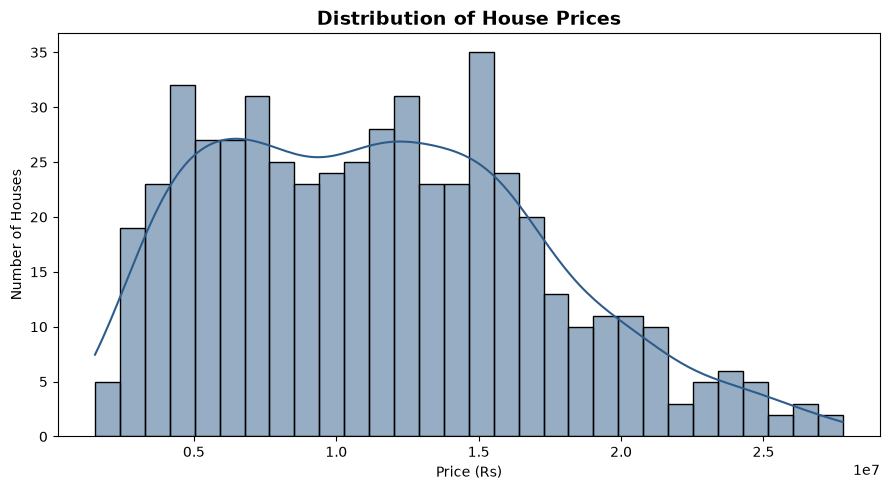

In [ ]:
#Histogram of price

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))
sns.histplot(ds["Price"], bins=30, kde=True, color='#2E5C8A')
plt.title("Distribution of House Prices", fontsize=14, fontweight="bold")
plt.xlabel("Price (Rs)")
plt.ylabel("Number of Houses")
plt.tight_layout()
plt.savefig("chart1_price_distribution.png")
plt.show()
plt.close()

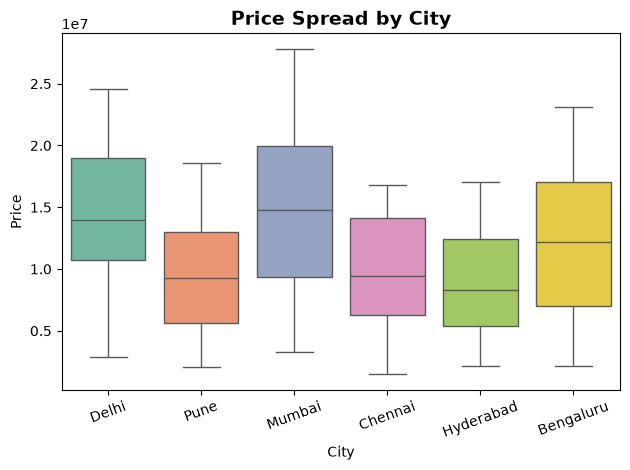

In [49]:
#Box Plot - Price by City

from enum import auto

plt.Figure(figsize=(10, 6))
sns.boxplot(data=ds, x="City", y="Price", hue="City", palette="Set2", legend=False)
#if plt.gca().get_legend():
 #   plt.gca().get_legend().remove()
plt.title("Price Spread by City", fontsize=14, fontweight="bold")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("chart2_price_by_city.png")
plt.show()
plt.close()

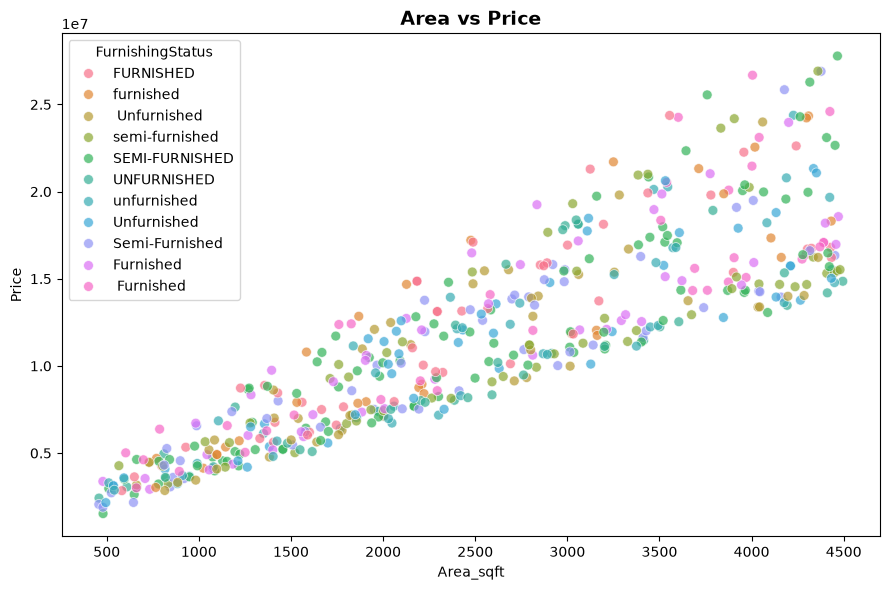

In [ ]:
#Scatter - Area vs Price

plt.figure(figsize=(9, 6))
sns.scatterplot(data=ds, x="Area_sqft", y="Price", hue="FurnishingStatus", alpha= 0.7, s=50)
plt.title("Area vs Price", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("chart3_area_vs_price.png")
plt.show()
plt.close()


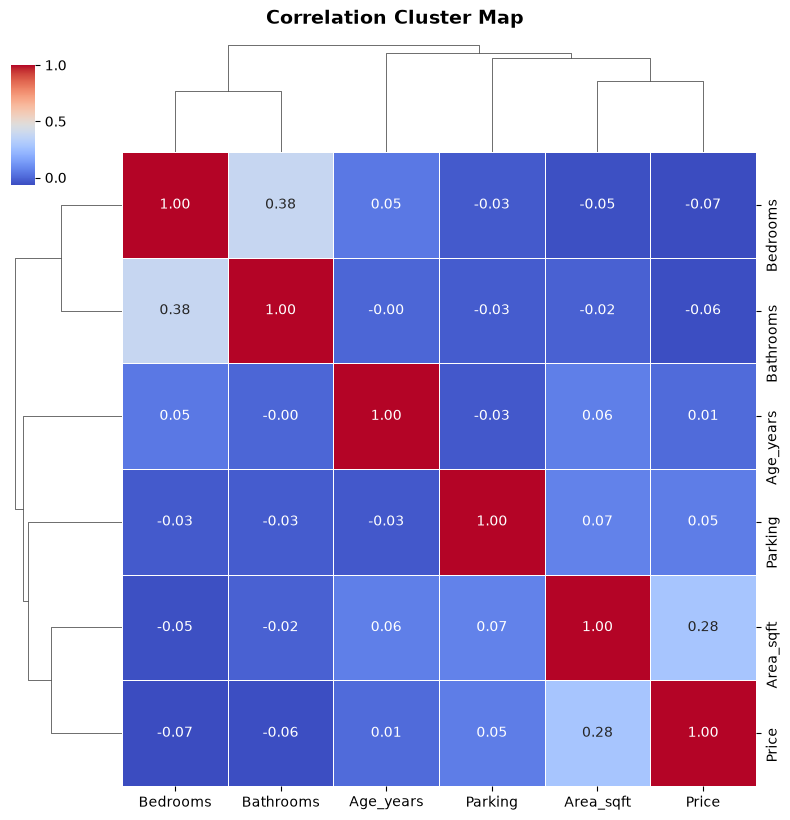

In [ ]:
# Cluster Map - Correlation map

df = pd.read_csv("house_prices.csv")
cols_needed = ["Area_sqft", "Bedrooms", "Bathrooms", "Age_years", "Parking", "Price"]
numeric_cols = df[cols_needed].apply(pd.to_numeric, errors="coerce").dropna()
corr_matrix = numeric_cols.corr(numeric_only=True)
g = sns.clustermap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.6,
    figsize=(8, 8),
    dendrogram_ratio=0.15,
    cbar_pos=(0.02, 0.8, 0.03, 0.15)
)
g.fig.suptitle("Correlation Cluster Map", fontsize=14, fontweight="bold", y=1.02)
g.savefig("chart4_clustermap.png", bbox_inches="tight")
plt.show()
plt.close()

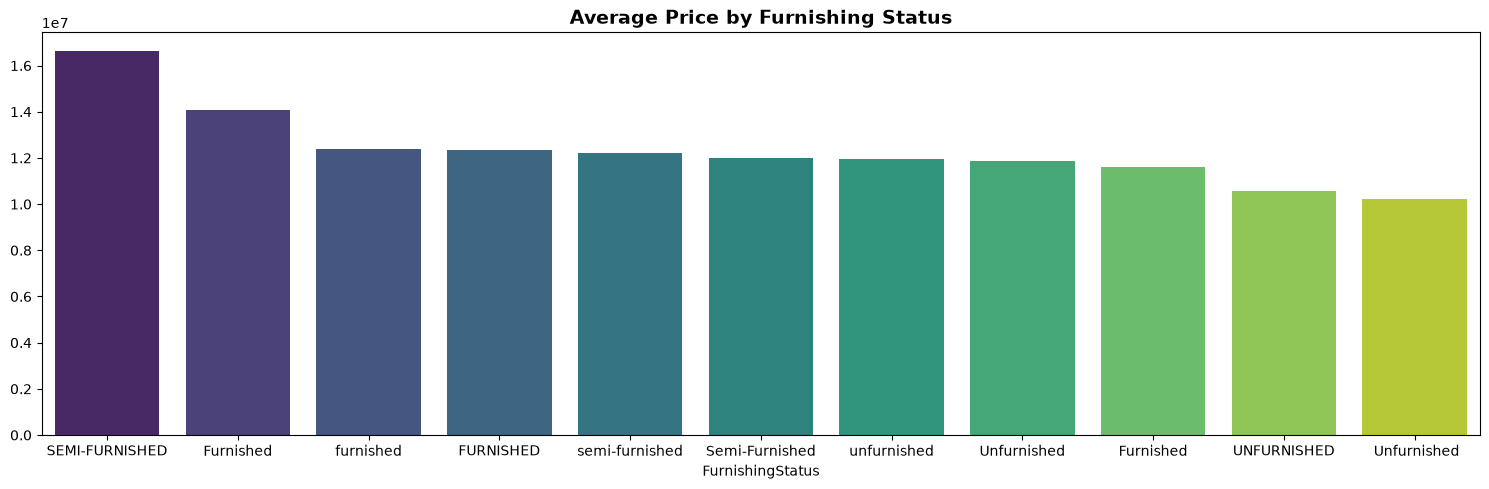

In [71]:
# Bar chart - Average Price by Furnishing
avg_price_furnish = df.groupby("FurnishingStatus")["Price"].mean().sort_values(ascending=False)

plt.figure(figsize=(15, 5))
sns.barplot(x=avg_price_furnish.index, y=avg_price_furnish.values,
            hue=avg_price_furnish.index, palette="viridis", legend=False)
plt.title("Average Price by Furnishing Status", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("chart5_avg_price_by_furnishing.png")
plt.show()
plt.close()